In [1]:
import math
import random
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.11.0+cpu


In [2]:
from google.colab import files

uploaded = files.upload()

Saving corpus.txt to corpus.txt
Saving merge_rules.txt to merge_rules.txt
Saving vocabulary.txt to vocabulary.txt


In [3]:
import base64

# Decode vocabulary
with open("vocabulary.txt","rb") as f:
    encoded=f.read()

decoded=base64.b64decode(encoded)

with open("vocabulary_decoded.txt","w") as f:
    f.write(decoded.decode())

# Decode merge rules
with open("merge_rules.txt","rb") as f:
    encoded=f.read()

decoded=base64.b64decode(encoded)

with open("merge_rules_decoded.txt","w") as f:
    f.write(decoded.decode())

print("Files decoded successfully.")

Files decoded successfully.


In [4]:
VOCAB_FILE = "vocabulary_decoded.txt"

In [5]:
VOCAB_FILE = "vocabulary.txt"

In [6]:
with open(VOCAB_FILE,"r") as f:
    vocabulary=[line.strip() for line in f if line.strip()]

print("Vocabulary Size:",len(vocabulary))

print(vocabulary[:20])

Vocabulary Size: 1
['PC93PgphCmFsCmFuCmFyCmF0CmIKYwpjaApjbwpkCmUKZTwvdz4KZW4KZXI8L3c+CmYKZwppCmljCmluCmluZzwvdz4KawpsCm0KbgpvCm9uPC93PgpwCnByCnBybwpyCnMKdAp0aAp0aQp0aW9uPC93Pgp1CnYKeQp6Cg==']


In [7]:
with open("vocabulary_decoded.txt", "r") as f:
    print(f.read())

</w>
a
al
an
ar
at
b
c
ch
co
d
e
e</w>
en
er</w>
f
g
i
ic
in
ing</w>
k
l
m
n
o
on</w>
p
pr
pro
r
s
t
th
ti
tion</w>
u
v
y
z



In [8]:
with open("vocabulary_decoded.txt", "r") as f:
    vocabulary = [line.strip() for line in f if line.strip()]

print("Vocabulary Size:", len(vocabulary))
print(vocabulary[:20])

Vocabulary Size: 40
['</w>', 'a', 'al', 'an', 'ar', 'at', 'b', 'c', 'ch', 'co', 'd', 'e', 'e</w>', 'en', 'er</w>', 'f', 'g', 'i', 'ic', 'in']


In [9]:
token_to_id = {token: idx for idx, token in enumerate(vocabulary)}
id_to_token = {idx: token for token, idx in token_to_id.items()}

print("Vocabulary Size:", len(token_to_id))
print("Token 'a' ID:", token_to_id["a"])
print("Token '</w>' ID:", token_to_id["</w>"])


Vocabulary Size: 40
Token 'a' ID: 1
Token '</w>' ID: 0


In [10]:
def tokenize_word(word, vocabulary):
    tokens = []
    i = 0

    while i < len(word):
        match = None

        # Find the longest matching token
        for j in range(len(word), i, -1):
            piece = word[i:j]
            if piece in vocabulary:
                match = piece
                break

        if match is None:
            match = word[i]

        tokens.append(match)
        i += len(match)

    tokens.append("</w>")
    return tokens

In [11]:
print(tokenize_word("machine", vocabulary))
print(tokenize_word("learning", vocabulary))
print(tokenize_word("tokenization", vocabulary))

['m', 'a', 'ch', 'in', 'e', '</w>']
['l', 'e', 'ar', 'n', 'in', 'g', '</w>']
['t', 'o', 'k', 'en', 'i', 'z', 'at', 'i', 'o', 'n', '</w>']


In [12]:
all_token_ids = []

for word in corpus:
    tokens = tokenize_word(word, vocabulary)

    ids = []

    for token in tokens:
        if token in token_to_id:
            ids.append(token_to_id[token])

    all_token_ids.extend(ids)

print("Total Token IDs:", len(all_token_ids))
print(all_token_ids[:50])

NameError: name 'corpus' is not defined

In [13]:
with open("corpus.txt", "r") as f:
    corpus = [line.strip().lower() for line in f if line.strip()]

print("Corpus Size:", len(corpus))
print(corpus)

Corpus Size: 6
['low', 'lower', 'lowest', 'new', 'newer', 'widest']


In [14]:
print("vocabulary:", "vocabulary" in globals())
print("token_to_id:", "token_to_id" in globals())
print("corpus:", "corpus" in globals())
print("tokenize_word:", "tokenize_word" in globals())

vocabulary: True
token_to_id: True
corpus: True
tokenize_word: True


In [15]:
all_token_ids = []

for word in corpus:
    tokens = tokenize_word(word, vocabulary)
    ids = [token_to_id[token] for token in tokens if token in token_to_id]
    all_token_ids.extend(ids)

print("Total Token IDs:", len(all_token_ids))
print(all_token_ids[:30])

Total Token IDs: 28
[22, 25, 0, 22, 25, 11, 30, 0, 22, 25, 11, 31, 32, 0, 24, 11, 0, 24, 11, 11, 30, 0, 17, 10, 11, 31, 32, 0]


In [16]:
with open("corpus.txt", "r") as f:
    print(f.read())

low
lower
lowest
new
newer
widest


In [17]:
with open("corpus.txt", "r") as f:
    corpus = [line.strip().lower() for line in f if line.strip()]

print(corpus)

['low', 'lower', 'lowest', 'new', 'newer', 'widest']


In [18]:
print("vocabulary:", "vocabulary" in globals())
print("token_to_id:", "token_to_id" in globals())
print("corpus:", "corpus" in globals())
print("tokenize_word:", "tokenize_word" in globals())

vocabulary: True
token_to_id: True
corpus: True
tokenize_word: True


In [19]:
all_token_ids = []

for word in corpus:
    tokens = tokenize_word(word, vocabulary)

    ids = []

    for token in tokens:
        if token in token_to_id:
            ids.append(token_to_id[token])

    all_token_ids.extend(ids)

print("All Token IDs:")
print(all_token_ids)
print("Total Tokens:", len(all_token_ids))

All Token IDs:
[22, 25, 0, 22, 25, 11, 30, 0, 22, 25, 11, 31, 32, 0, 24, 11, 0, 24, 11, 11, 30, 0, 17, 10, 11, 31, 32, 0]
Total Tokens: 28


In [20]:
with open("corpus.txt", "r") as f:
    corpus = []

    for line in f:
        words = line.lower().split()
        corpus.extend(words)

print("Total Words:", len(corpus))
print(corpus[:20])

Total Words: 188
['artificial', 'intelligence', 'is', 'transforming', 'technology', 'machine', 'learning', 'enables', 'computers', 'to', 'learn', 'from', 'data', 'deep', 'learning', 'uses', 'neural', 'networks', 'natural', 'language']


In [21]:
all_token_ids = []

for word in corpus:

    tokens = tokenize_word(word, vocabulary)

    ids = []

    for token in tokens:
        if token in token_to_id:
            ids.append(token_to_id[token])

    all_token_ids.extend(ids)

print("Total Token IDs:", len(all_token_ids))
print(all_token_ids[:50])

Total Token IDs: 1267
[4, 34, 15, 18, 17, 2, 0, 19, 32, 11, 22, 22, 17, 16, 13, 7, 11, 0, 17, 31, 0, 32, 30, 3, 31, 15, 25, 30, 23, 19, 16, 0, 32, 11, 8, 24, 25, 22, 25, 16, 38, 0, 23, 1, 8, 19, 11, 0, 22, 11]


In [22]:
sequence_length = 8

inputs = []
targets = []

for i in range(len(all_token_ids) - sequence_length):

    inputs.append(all_token_ids[i:i+sequence_length])
    targets.append(all_token_ids[i+sequence_length])

print("Training Samples:", len(inputs))
print("First Input:", inputs[0])
print("First Target:", targets[0])

Training Samples: 1259
First Input: [4, 34, 15, 18, 17, 2, 0, 19]
First Target: 32


In [23]:
X = torch.tensor(inputs, dtype=torch.long)
Y = torch.tensor(targets, dtype=torch.long)

print(X.shape)
print(Y.shape)

torch.Size([1259, 8])
torch.Size([1259])


In [24]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X, Y)

train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print("Batches:", len(train_loader))

Batches: 40


In [25]:
VOCAB_SIZE = len(vocabulary)
EMBED_DIM = 64
NUM_HEADS = 4
NUM_LAYERS = 2
SEQ_LEN = 8


In [26]:
import math
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):

    def __init__(self, embed_dim, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, embed_dim)

        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0, embed_dim, 2).float()
            * (-math.log(10000.0) / embed_dim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [27]:
class ARLanguageModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, seq_len):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.position = PositionalEncoding(embed_dim, seq_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):

        x = self.embedding(x)

        x = self.position(x)

        mask = torch.triu(
            torch.ones(x.size(1), x.size(1)),
            diagonal=1
        ).bool().to(x.device)

        x = self.transformer(x, mask=mask)

        x = self.fc(x)

        return x

In [28]:
model = ARLanguageModel(
    VOCAB_SIZE,
    EMBED_DIM,
    NUM_HEADS,
    NUM_LAYERS,
    SEQ_LEN
)

print(model)

ARLanguageModel(
  (embedding): Embedding(40, 64)
  (position): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=40, bias=True)
)


In [29]:
sample = X[:2]

output = model(sample)

print(output.shape)

torch.Size([2, 8, 40])


In [30]:
print(output.shape)

torch.Size([2, 8, 40])


In [31]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss and Optimizer Initialized!")

Loss and Optimizer Initialized!


In [32]:
num_epochs = 20

for epoch in range(num_epochs):

    total_loss = 0

    for batch_x, batch_y in train_loader:

        optimizer.zero_grad()

        # Forward pass
        outputs = model(batch_x)

        # Only use the last token prediction
        outputs = outputs[:, -1, :]

        # Compute loss
        loss = criterion(outputs, batch_y)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

Epoch 1/20 - Loss: 3.1593
Epoch 2/20 - Loss: 2.7703
Epoch 3/20 - Loss: 2.5727
Epoch 4/20 - Loss: 2.4081
Epoch 5/20 - Loss: 2.2770
Epoch 6/20 - Loss: 2.1211
Epoch 7/20 - Loss: 1.9936
Epoch 8/20 - Loss: 1.8871
Epoch 9/20 - Loss: 1.6995
Epoch 10/20 - Loss: 1.6036
Epoch 11/20 - Loss: 1.4930
Epoch 12/20 - Loss: 1.3524
Epoch 13/20 - Loss: 1.2792
Epoch 14/20 - Loss: 1.1728
Epoch 15/20 - Loss: 1.0636
Epoch 16/20 - Loss: 0.9627
Epoch 17/20 - Loss: 0.8685
Epoch 18/20 - Loss: 0.8182
Epoch 19/20 - Loss: 0.7396
Epoch 20/20 - Loss: 0.6913


In [33]:
torch.save(model.state_dict(), "arlm_model.pth")

print("Model saved successfully!")

Model saved successfully!


In [34]:
loaded_model = ARLanguageModel(
    VOCAB_SIZE,
    EMBED_DIM,
    NUM_HEADS,
    NUM_LAYERS,
    SEQ_LEN
)

loaded_model.load_state_dict(torch.load("arlm_model.pth"))
loaded_model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [35]:
def generate_text(start_tokens, max_new_tokens=10):
    model.eval()

    tokens = start_tokens.copy()

    with torch.no_grad():
        for _ in range(max_new_tokens):

            input_tokens = torch.tensor(
                [tokens[-SEQ_LEN:]],
                dtype=torch.long
            )

            # Pad if sequence is shorter than SEQ_LEN
            if input_tokens.shape[1] < SEQ_LEN:
                padding = torch.zeros(
                    (1, SEQ_LEN - input_tokens.shape[1]),
                    dtype=torch.long
                )
                input_tokens = torch.cat((padding, input_tokens), dim=1)

            outputs = model(input_tokens)

            next_token = torch.argmax(outputs[:, -1, :], dim=-1).item()

            tokens.append(next_token)

    return tokens

In [36]:
start = inputs[0]

generated_ids = generate_text(start, max_new_tokens=10)

print(generated_ids)


[4, 34, 15, 18, 17, 2, 0, 19, 32, 11, 22, 22, 17, 16, 13, 7, 11, 0]


In [37]:
generated_tokens = [id_to_token[token_id] for token_id in generated_ids]

print("Generated Tokens:")
print(generated_tokens)

Generated Tokens:
['ar', 'ti', 'f', 'ic', 'i', 'al', '</w>', 'in', 't', 'e', 'l', 'l', 'i', 'g', 'en', 'c', 'e', '</w>']


In [38]:
with open("generated_text.txt", "w") as f:
    f.write(" ".join(generated_tokens))

print("Generated text saved to generated_text.txt")

Generated text saved to generated_text.txt


In [39]:
def predict_next_token(prompt_words):
    """
    Predict the next token after a prompt.
    """

    # Convert words into token IDs
    token_ids = []

    for word in prompt_words:
        tokens = tokenize_word(word.lower(), vocabulary)

        for token in tokens:
            if token in token_to_id:
                token_ids.append(token_to_id[token])

    # Keep only the last SEQ_LEN tokens
    token_ids = token_ids[-SEQ_LEN:]

    # Pad if necessary
    while len(token_ids) < SEQ_LEN:
        token_ids.insert(0, token_to_id["</w>"])

    x = torch.tensor([token_ids], dtype=torch.long)

    model.eval()

    with torch.no_grad():
        output = model(x)
        next_id = torch.argmax(output[:, -1, :], dim=-1).item()

    print("Prompt:", " ".join(prompt_words))
    print("Predicted Token:", id_to_token[next_id])

In [40]:
predict_next_token(["machine", "learning"])

Prompt: machine learning
Predicted Token: pro


In [41]:
predict_next_token(["artificial", "intelligence"])

Prompt: artificial intelligence
Predicted Token: i


In [42]:
predict_next_token(["deep", "learning"])

Prompt: deep learning
Predicted Token: pro


In [43]:
predict_next_token(["i", "love"])

Prompt: i love
Predicted Token: co


In [44]:
predict_next_token(["i", "love"])

Prompt: i love
Predicted Token: co


In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.savefig("training_loss.png")
plt.show()

NameError: name 'loss_history' is not defined

<Figure size 800x500 with 0 Axes>

In [47]:

loss_history = []

num_epochs = 20

for epoch in range(num_epochs):

    model.train()
    total_loss = 0

    for batch_x, batch_y in train_loader:

        optimizer.zero_grad()

        outputs = model(batch_x)

        outputs = outputs[:, -1, :]

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Loss = {avg_loss:.4f}")

Epoch 1/20 | Loss = 0.6047
Epoch 2/20 | Loss = 0.5916
Epoch 3/20 | Loss = 0.5553
Epoch 4/20 | Loss = 0.5185
Epoch 5/20 | Loss = 0.5208
Epoch 6/20 | Loss = 0.4914
Epoch 7/20 | Loss = 0.4568
Epoch 8/20 | Loss = 0.4117
Epoch 9/20 | Loss = 0.3985
Epoch 10/20 | Loss = 0.4164
Epoch 11/20 | Loss = 0.3778
Epoch 12/20 | Loss = 0.3507
Epoch 13/20 | Loss = 0.3346
Epoch 14/20 | Loss = 0.3147
Epoch 15/20 | Loss = 0.3072
Epoch 16/20 | Loss = 0.2597
Epoch 17/20 | Loss = 0.2471
Epoch 18/20 | Loss = 0.2555
Epoch 19/20 | Loss = 0.2598
Epoch 20/20 | Loss = 0.2620


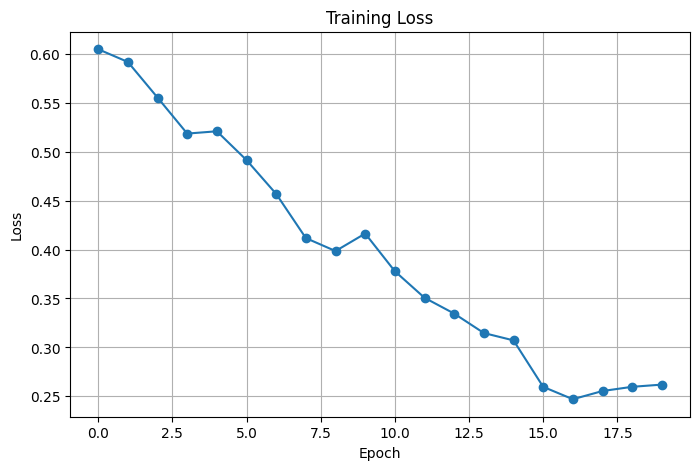

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_history, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [49]:
plt.savefig("training_loss.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>